In [31]:
"""
2D 時間序列特徵工程 + 濃縮摘要特徵
- 保留原本攤平的月份特徵 (m_* 與 roll3 / roll6)
- 額外加上每個會員、每個指標的濃縮摘要特徵:
  Trend 斜率 / ROC 動能 / 波動度 std / EMA(最後值) / 活躍月數 / 距今最後活躍月
"""
import pandas as pd
import numpy as np

print("開始處理時間序列資料...")

# ==========================================
# 1. 讀取通話與銷售明細，進行基礎特徵工程
# ==========================================
df = pd.read_csv('(all)merged_call_sales_data.csv')
df['call_date'] = pd.to_datetime(df['call_date'])
df = df[df['call_date'].dt.year <= 2022].copy()
#df = df[(df['call_date'].dt.year >= 2021) & (df['call_date'].dt.year <= 2022)].copy()
df['total_price'] = df['total_price'].fillna(0)

df['is_pickup'] = (df['call_time_sec'] > 0).astype(int)
df['has_order'] = df['sales_order_number'].notnull().astype(int)
df['is_unreachable'] = (df['call_status_2'] == '沒聯絡上本人').astype(int)

df['year_month'] = df['call_date'].dt.to_period('M')

# ==========================================
# 2. 讀取原本的靜態特徵與標籤
# ==========================================
original_model_data = pd.read_csv('all_model_data(20~22).csv')
valid_members = original_model_data['member_id'].unique()

# ==========================================
# 3. 每月聚合與補零 (Zero-Padding)
# ==========================================
metrics = ['m_spend', 'm_purchases', 'm_calls', 'm_avg_call_time', 'm_pickup_rate', 'm_unreachable_rate']

monthly_data = df.groupby(['member_id', 'year_month']).agg(
    m_spend=('total_price', 'sum'),
    m_purchases=('has_order', 'sum'),
    m_calls=('call_id', 'count'),
    m_avg_call_time=('call_time_sec', 'mean'),
    m_pickup_rate=('is_pickup', 'mean'),
    m_unreachable_rate=('is_unreachable', 'mean')
).reset_index()

# 完整 36 個月時間網格
all_months = pd.period_range(start=df['year_month'].min(), end=df['year_month'].max(), freq='M')
n_months = len(all_months)
print(f"時間網格涵蓋 {n_months} 個月: {all_months.min()} ~ {all_months.max()}")

multi_idx = pd.MultiIndex.from_product([valid_members, all_months], names=['member_id', 'year_month'])
full_time_grid = pd.DataFrame(index=multi_idx).reset_index()

ts_full_data = pd.merge(full_time_grid, monthly_data, on=['member_id', 'year_month'], how='left').fillna(0)
ts_full_data = ts_full_data.sort_values(['member_id', 'year_month']).reset_index(drop=True)

# ==========================================
# 3.5 Rolling Statistics (3 / 6 個月移動平均)
# ==========================================
print("正在計算近期行為統計量 (3個月與6個月移動窗口)...")
for m in metrics:
    ts_full_data[f'{m}_roll3'] = ts_full_data.groupby('member_id')[m].transform(lambda x: x.rolling(3).mean())
    ts_full_data[f'{m}_roll6'] = ts_full_data.groupby('member_id')[m].transform(lambda x: x.rolling(6).mean())
ts_full_data = ts_full_data.fillna(0)

# ==========================================
# 4. 攤平為 2D 時間特徵表
# ==========================================
print("正在攤平月份特徵...")
feature_cols = metrics + [f'{m}_roll3' for m in metrics] + [f'{m}_roll6' for m in metrics]
ts_flattened = ts_full_data.pivot(index='member_id', columns='year_month', values=feature_cols)
ts_flattened.columns = [f"{i}_{j}" for i, j in ts_flattened.columns]
ts_flattened = ts_flattened.reset_index()
ts_flattened.columns.name = None
print(f"攤平特徵表形狀: {ts_flattened.shape}")

# ==========================================
# 5. 【新增】濃縮摘要特徵 (每會員每指標一組)
#    Trend / ROC / 波動度 / EMA / 活躍月數 / 距今最後活躍月
# ==========================================
print("正在計算濃縮摘要特徵 (Trend / ROC / 波動度 / EMA / 活躍度)...")
EPS = 1e-9
x_axis = np.arange(n_months)            # 月份序號 0..n-1，用於 polyfit 斜率
month_index = np.arange(n_months)       # 用於活躍月計算

summary_rows = []
# 以 member 分組，序列已依 year_month 排序
for mid, g in ts_full_data.groupby('member_id'):
    row = {'member_id': mid}
    for m in metrics:
        series = g[m].to_numpy(dtype=float)

        # (a) Trend 斜率：對 36 個月做一階多項式擬合取斜率
        if np.allclose(series, series[0]):
            slope = 0.0
        else:
            slope = np.polyfit(x_axis, series, 1)[0]
        row[f'{m}_trend_slope'] = slope

        # (b) ROC 動能：(近3月均值 - 前3月均值) / (前3月均值 + eps)
        recent3 = series[-3:].mean()
        prev3 = series[-6:-3].mean()
        row[f'{m}_roc3'] = (recent3 - prev3) / (abs(prev3) + EPS)

        # (c) 波動度：整段標準差
        row[f'{m}_std'] = series.std()

        # (d) EMA 最後值：指數移動平均 (span=6) 的最終值
        ema_last = pd.Series(series).ewm(span=6, adjust=False).mean().iloc[-1]
        row[f'{m}_ema_last'] = ema_last

        # (e) 活躍月數：非零月份計數
        active_mask = series > 0
        row[f'{m}_active_months'] = int(active_mask.sum())

        # (f) 距今最後活躍月：最後一個非零月距最後一個月(序號 n-1)的月數；全零填 n_months
        if active_mask.any():
            last_active_idx = month_index[active_mask].max()
            row[f'{m}_months_since_active'] = int((n_months - 1) - last_active_idx)
        else:
            row[f'{m}_months_since_active'] = n_months

    summary_rows.append(row)

summary_features = pd.DataFrame(summary_rows)
print(f"濃縮摘要特徵表形狀: {summary_features.shape} (含 member_id)")

# ==========================================
# 6. 終極合併與存檔
# ==========================================
xgb_data = pd.merge(original_model_data, ts_flattened, on='member_id', how='inner')
xgb_data = pd.merge(xgb_data, summary_features, on='member_id', how='inner')

buy_summary = pd.read_csv("buy_summary_(20~22).csv")
xgb_data = xgb_data.merge(buy_summary, on="member_id", how="left")
xgb_data[['has_buy_2021','has_buy_2022H1','has_buy_2022H2']] = \
    xgb_data[['has_buy_2021','has_buy_2022H1','has_buy_2022H2']].fillna(0)


print("\n✅ 資料處理大功告成！")
print(f"🔹 最終 XGBoost 特徵大表形狀: {xgb_data.shape}")
print(f"🔹 其中濃縮摘要特徵共 {summary_features.shape[1] - 1} 欄 (6 指標 × 6 種摘要)")

out_path = 'outputs/(all)model_timeseries_data(20~22).csv'
xgb_data.to_csv('(all)model_timeseries_data(20~22).csv', index=False)
print("已儲存資料集: (all)model_timeseries_data(20~22).csv")

# 額外：列出新增的摘要欄位名稱，方便檢查
summary_cols = [c for c in summary_features.columns if c != 'member_id']
print("\n新增的摘要特徵欄位:")
for i in range(0, len(summary_cols), 6):
    print("  " + ", ".join(summary_cols[i:i+6]))

開始處理時間序列資料...


/var/folders/bc/3gcv0zzj4fgcc8gzvkdcr1940000gn/T/ipykernel_28975/4040366591.py:15: DtypeWarning: Columns (0: product_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('(all)merged_call_sales_data.csv')


時間網格涵蓋 36 個月: 2020-01 ~ 2022-12
正在計算近期行為統計量 (3個月與6個月移動窗口)...
正在攤平月份特徵...
攤平特徵表形狀: (57916, 649)
正在計算濃縮摘要特徵 (Trend / ROC / 波動度 / EMA / 活躍度)...
濃縮摘要特徵表形狀: (57916, 37) (含 member_id)

✅ 資料處理大功告成！
🔹 最終 XGBoost 特徵大表形狀: (57916, 697)
🔹 其中濃縮摘要特徵共 36 欄 (6 指標 × 6 種摘要)
已儲存資料集: (all)model_timeseries_data(20~22).csv

新增的摘要特徵欄位:
  m_spend_trend_slope, m_spend_roc3, m_spend_std, m_spend_ema_last, m_spend_active_months, m_spend_months_since_active
  m_purchases_trend_slope, m_purchases_roc3, m_purchases_std, m_purchases_ema_last, m_purchases_active_months, m_purchases_months_since_active
  m_calls_trend_slope, m_calls_roc3, m_calls_std, m_calls_ema_last, m_calls_active_months, m_calls_months_since_active
  m_avg_call_time_trend_slope, m_avg_call_time_roc3, m_avg_call_time_std, m_avg_call_time_ema_last, m_avg_call_time_active_months, m_avg_call_time_months_since_active
  m_pickup_rate_trend_slope, m_pickup_rate_roc3, m_pickup_rate_std, m_pickup_rate_ema_last, m_pickup_rate_active_months, m_pickup_rate_mo

In [16]:
"""
2D 時間序列特徵工程 + 濃縮摘要特徵
- 保留原本攤平的月份特徵 (m_* 與 roll3 / roll6)
- 額外加上每個會員、每個指標的濃縮摘要特徵:
  Trend 斜率 / ROC 動能 / 波動度 std / EMA(最後值) / 活躍月數 / 距今最後活躍月
"""
import pandas as pd
import numpy as np

print("開始處理時間序列資料...")

# ==========================================
# 1. 讀取通話與銷售明細，進行基礎特徵工程
# ==========================================
df = pd.read_csv('merged_call_sales_data.csv')
df['call_date'] = pd.to_datetime(df['call_date'])
df = df[df['call_date'].dt.year <= 2022].copy()
#df = df[(df['call_date'].dt.year >= 2021) & (df['call_date'].dt.year <= 2022)].copy()
df['total_price'] = df['total_price'].fillna(0)

df['is_pickup'] = (df['call_time_sec'] > 0).astype(int)
df['has_order'] = df['sales_order_number'].notnull().astype(int)
df['is_unreachable'] = (df['call_status_2'] == '沒聯絡上本人').astype(int)

df['year_month'] = df['call_date'].dt.to_period('M')

# ==========================================
# 2. 讀取原本的靜態特徵與標籤
# ==========================================
original_model_data = pd.read_csv('model_data(20~22).csv')
valid_members = original_model_data['member_id'].unique()

# ==========================================
# 3. 每月聚合與補零 (Zero-Padding)
# ==========================================
metrics = ['m_spend', 'm_purchases', 'm_calls', 'm_avg_call_time', 'm_pickup_rate', 'm_unreachable_rate']

monthly_data = df.groupby(['member_id', 'year_month']).agg(
    m_spend=('total_price', 'sum'),
    m_purchases=('has_order', 'sum'),
    m_calls=('call_id', 'count'),
    m_avg_call_time=('call_time_sec', 'mean'),
    m_pickup_rate=('is_pickup', 'mean'),
    m_unreachable_rate=('is_unreachable', 'mean')
).reset_index()

# 完整 36 個月時間網格
all_months = pd.period_range(start=df['year_month'].min(), end=df['year_month'].max(), freq='M')
n_months = len(all_months)
print(f"時間網格涵蓋 {n_months} 個月: {all_months.min()} ~ {all_months.max()}")

multi_idx = pd.MultiIndex.from_product([valid_members, all_months], names=['member_id', 'year_month'])
full_time_grid = pd.DataFrame(index=multi_idx).reset_index()

ts_full_data = pd.merge(full_time_grid, monthly_data, on=['member_id', 'year_month'], how='left').fillna(0)
ts_full_data = ts_full_data.sort_values(['member_id', 'year_month']).reset_index(drop=True)

# ==========================================
# 3.5 Rolling Statistics (3 / 6 個月移動平均)
# ==========================================
print("正在計算近期行為統計量 (3個月與6個月移動窗口)...")
for m in metrics:
    ts_full_data[f'{m}_roll3'] = ts_full_data.groupby('member_id')[m].transform(lambda x: x.rolling(3).mean())
    ts_full_data[f'{m}_roll6'] = ts_full_data.groupby('member_id')[m].transform(lambda x: x.rolling(6).mean())
ts_full_data = ts_full_data.fillna(0)

# ==========================================
# 4. 攤平為 2D 時間特徵表
# ==========================================
print("正在攤平月份特徵...")
feature_cols = metrics + [f'{m}_roll3' for m in metrics] + [f'{m}_roll6' for m in metrics]
ts_flattened = ts_full_data.pivot(index='member_id', columns='year_month', values=feature_cols)
ts_flattened.columns = [f"{i}_{j}" for i, j in ts_flattened.columns]
ts_flattened = ts_flattened.reset_index()
ts_flattened.columns.name = None
print(f"攤平特徵表形狀: {ts_flattened.shape}")

# ==========================================
# 5. 【新增】濃縮摘要特徵 (每會員每指標一組)
#    Trend / ROC / 波動度 / EMA / 活躍月數 / 距今最後活躍月
# ==========================================
print("正在計算濃縮摘要特徵 (Trend / ROC / 波動度 / EMA / 活躍度)...")
EPS = 1e-9
x_axis = np.arange(n_months)            # 月份序號 0..n-1，用於 polyfit 斜率
month_index = np.arange(n_months)       # 用於活躍月計算

summary_rows = []
# 以 member 分組，序列已依 year_month 排序
for mid, g in ts_full_data.groupby('member_id'):
    row = {'member_id': mid}
    for m in metrics:
        series = g[m].to_numpy(dtype=float)

        # (a) Trend 斜率：對 36 個月做一階多項式擬合取斜率
        if np.allclose(series, series[0]):
            slope = 0.0
        else:
            slope = np.polyfit(x_axis, series, 1)[0]
        row[f'{m}_trend_slope'] = slope

        # (b) ROC 動能：(近3月均值 - 前3月均值) / (前3月均值 + eps)
        recent3 = series[-3:].mean()
        prev3 = series[-6:-3].mean()
        row[f'{m}_roc3'] = (recent3 - prev3) / (abs(prev3) + EPS)

        # (c) 波動度：整段標準差
        row[f'{m}_std'] = series.std()

        # (d) EMA 最後值：指數移動平均 (span=6) 的最終值
        ema_last = pd.Series(series).ewm(span=6, adjust=False).mean().iloc[-1]
        row[f'{m}_ema_last'] = ema_last

        # (e) 活躍月數：非零月份計數
        active_mask = series > 0
        row[f'{m}_active_months'] = int(active_mask.sum())

        # (f) 距今最後活躍月：最後一個非零月距最後一個月(序號 n-1)的月數；全零填 n_months
        if active_mask.any():
            last_active_idx = month_index[active_mask].max()
            row[f'{m}_months_since_active'] = int((n_months - 1) - last_active_idx)
        else:
            row[f'{m}_months_since_active'] = n_months

    summary_rows.append(row)

summary_features = pd.DataFrame(summary_rows)
print(f"濃縮摘要特徵表形狀: {summary_features.shape} (含 member_id)")

# ==========================================
# 6. 終極合併與存檔
# ==========================================
xgb_data = pd.merge(original_model_data, ts_flattened, on='member_id', how='inner')
xgb_data = pd.merge(xgb_data, summary_features, on='member_id', how='inner')

print("\n✅ 資料處理大功告成！")
print(f"🔹 最終 XGBoost 特徵大表形狀: {xgb_data.shape}")
print(f"🔹 其中濃縮摘要特徵共 {summary_features.shape[1] - 1} 欄 (6 指標 × 6 種摘要)")

out_path = 'outputs/model_timeseries_data(20~22).csv'
xgb_data.to_csv('model_timeseries_data(20~22).csv', index=False)
print("已儲存資料集: model_timeseries_data(20~22).csv")

# 額外：列出新增的摘要欄位名稱，方便檢查
summary_cols = [c for c in summary_features.columns if c != 'member_id']
print("\n新增的摘要特徵欄位:")
for i in range(0, len(summary_cols), 6):
    print("  " + ", ".join(summary_cols[i:i+6]))

開始處理時間序列資料...
時間網格涵蓋 36 個月: 2020-01 ~ 2022-12
正在計算近期行為統計量 (3個月與6個月移動窗口)...
正在攤平月份特徵...
攤平特徵表形狀: (2407, 649)
正在計算濃縮摘要特徵 (Trend / ROC / 波動度 / EMA / 活躍度)...
濃縮摘要特徵表形狀: (2407, 37) (含 member_id)

✅ 資料處理大功告成！
🔹 最終 XGBoost 特徵大表形狀: (2407, 694)
🔹 其中濃縮摘要特徵共 36 欄 (6 指標 × 6 種摘要)
已儲存資料集: model_timeseries_data(20~22).csv

新增的摘要特徵欄位:
  m_spend_trend_slope, m_spend_roc3, m_spend_std, m_spend_ema_last, m_spend_active_months, m_spend_months_since_active
  m_purchases_trend_slope, m_purchases_roc3, m_purchases_std, m_purchases_ema_last, m_purchases_active_months, m_purchases_months_since_active
  m_calls_trend_slope, m_calls_roc3, m_calls_std, m_calls_ema_last, m_calls_active_months, m_calls_months_since_active
  m_avg_call_time_trend_slope, m_avg_call_time_roc3, m_avg_call_time_std, m_avg_call_time_ema_last, m_avg_call_time_active_months, m_avg_call_time_months_since_active
  m_pickup_rate_trend_slope, m_pickup_rate_roc3, m_pickup_rate_std, m_pickup_rate_ema_last, m_pickup_rate_active_months, m_pickup_r

正在讀取資料...
[0 1 2]

🚀 正在訓練 XGBoost 模型...
訓練完成！

模型已儲存為 time_xgb_model.json
============== 最佳 Threshold ==============
最佳 class2 門檻 t2 = 0.44
最佳 class1 門檻 t1 = 0.42
最佳 Macro F1 = 0.6760

============== 最佳 Threshold 的預測結果 ==============
Accuracy: 0.9862741712707183
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     11385
           1       0.47      0.50      0.48       133
           2       0.55      0.55      0.55        66

    accuracy                           0.99     11584
   macro avg       0.67      0.68      0.68     11584
weighted avg       0.99      0.99      0.99     11584



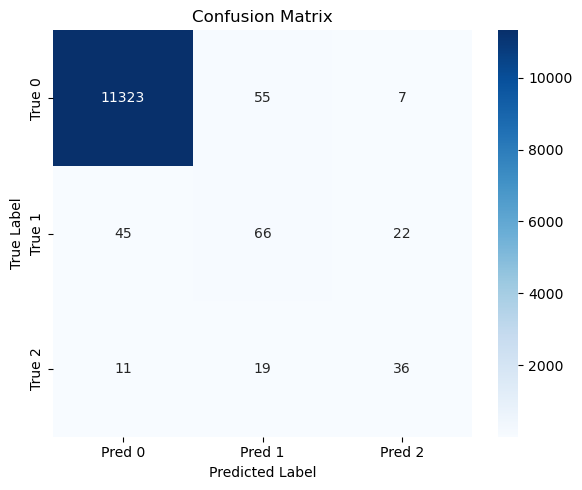

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("正在讀取資料...")
final_xgb_data = pd.read_csv('(all)model_timeseries_data(20~22).csv')

# 1. X, y
X = final_xgb_data.drop(columns=['member_id', 'target'])
y = final_xgb_data['target']

# 2. Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(le.classes_)

# 3. Train/Test Split (使用 stratify 保持類別比例)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 4. 計算 scale_pos_weight 
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_res
)

# 5. XGBoost 模型調整
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=7,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    objective='multi:softprob',   
    eval_metric='mlogloss',       
    n_jobs=-1            
    
)

print("\n🚀 正在訓練 XGBoost 模型...")
model.fit(X_train_res, y_train_res, sample_weight=sample_weights)
print("訓練完成！\n")
# ===== 儲存模型 =====
model.save_model("time_xgb_model.json")
print("模型已儲存為 time_xgb_model.json")


# ===== 使用 predict_proba 取得每一類的機率 =====
proba = model.predict_proba(X_test)  # 注意：這裡應該是 X_test 而不是 X_validate，請確認變數名稱是否正確

best_f1 = -1
best_t1 = None
best_t2 = None
best_pred = None

# t2 = class 2 門檻
# t1 = class 1 門檻
for t2 in np.arange(0.20, 0.51, 0.02):   # 0.20 ~ 0.50
    for t1 in np.arange(0.20, t2, 0.02): # class1 門檻必須 < class2
        y_temp = []
        for p in proba:
            if p[2] > t2:
                y_temp.append(2)
            elif p[1] > t1:
                y_temp.append(1)
            else:
                y_temp.append(0)

        macro_f1 = f1_score(y_test, y_temp, average='macro')

        if macro_f1 > best_f1:
            best_f1 = macro_f1
            best_t1 = t1
            best_t2 = t2
            best_pred = y_temp

print("============== 最佳 Threshold ==============")
print(f"最佳 class2 門檻 t2 = {best_t2:.2f}")
print(f"最佳 class1 門檻 t1 = {best_t1:.2f}")
print(f"最佳 Macro F1 = {best_f1:.4f}")

print("\n============== 最佳 Threshold 的預測結果 ==============")
print("Accuracy:", accuracy_score(y_test, best_pred))
print(classification_report(y_test, best_pred))

# ===== 混淆矩陣 =====
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1', 'Pred 2'],
            yticklabels=['True 0', 'True 1', 'True 2'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [40]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.utils import to_categorical

# 1. 讀取資料
data = pd.read_csv('(all)model_timeseries_data(20~22).csv')
X = data.drop(columns=['member_id', 'target']).select_dtypes(include=[np.number]).fillna(0)
y = data['target']

# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

# ===== 重要：只 split 一次，兩個模型共用 =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 2. XGBoost
model_xgb = XGBClassifier(n_estimators=500, learning_rate=0.01)
model_xgb.fit(X_train, y_train)

# 3. LSTM：正規化 + reshape
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_l = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_l = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

y_train_l = to_categorical(y_train)
y_test_l = to_categorical(y_test)

model_lstm = Sequential([
    LSTM(64, input_shape=(1, X_train.shape[1])),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
model_lstm.compile(optimizer='adam', loss='categorical_crossentropy')
model_lstm.fit(X_train_l, y_train_l, epochs=10, verbose=0)

# 4. Ensemble
xgb_probs = model_xgb.predict_proba(X_test)
lstm_probs = model_lstm.predict(X_test_l)

final_probs = 0.7 * xgb_probs + 0.3 * lstm_probs
final_preds = np.argmax(final_probs, axis=1)

# 5. 結果
print("============== 混合模型預測結果 ==============")
print(classification_report(y_test, final_preds))


/opt/anaconda3/envs/peter/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
============== 混合模型預測結果 ==============
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     11385
           1       0.54      0.46      0.49       133
           2       0.60      0.52      0.55        66

    accuracy                           0.99     11584
   macro avg       0.71      0.66      0.68     11584
weighted avg       0.99      0.99      0.99     11584



In [41]:
# 儲存 XGBoost
model_xgb.save_model("xgb_model.json")

# 儲存 LSTM
model_lstm.save("lstm_model.keras")

# 儲存 ensemble 權重
import json
json.dump({"xgb_weight": 0.6, "lstm_weight": 0.4}, open("ensemble_weights.json", "w"))
